# Chapter 15 — Deep learning on unseen data

*Grokking Deep Learning* — Andrew W. Trask

Chapter ini membahas masalah **privacy dalam deep learning** dan memperkenalkan **federated learning**, kemudian menunjukkan mengapa model federated masih dapat membocorkan informasi. Solusinya dilanjutkan dengan **secure aggregation** dan **homomorphic encryption**.

## Learning Objectives

Setelah menyelesaikan chapter ini, kita diharapkan dapat:

1. Menjelaskan mengapa training data dapat menjadi masalah privacy.
2. Memahami prinsip **federated learning**.
3. Memahami contoh **spam detection** yang digunakan buku.
4. Menjelaskan bagaimana weight update dapat membocorkan informasi.
5. Memahami konsep **secure aggregation**.
6. Memahami bagaimana **homomorphic encryption** memungkinkan operasi pada data terenkripsi.
7. Menjelaskan bagaimana kedua konsep tersebut digunakan untuk melindungi federated learning.

## Chapter Roadmap

**Privacy problem → Federated learning → Spam detection → Federated training → Information leakage → Secure aggregation → Homomorphic encryption → Homomorphically encrypted federated learning**

## The Problem of Privacy in Deep Learning

Deep learning membutuhkan training data. Masalah muncul ketika data tersebut bersifat personal atau sensitif.

Buku mengajukan pembalikan sederhana:

**Bukan membawa data ke model, tetapi membawa model ke data.**

Dengan pendekatan ini, data dapat tetap berada di lingkungan tempat data tersebut dibuat, sementara model belajar dari data lokal.

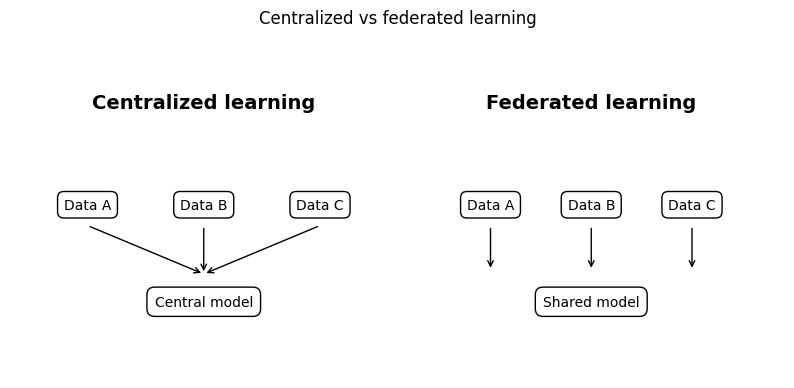

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axis("off")

# Centralized learning
ax.text(0.25, 0.78, "Centralized learning", ha="center",
        fontsize=14, fontweight="bold")
ax.text(0.10, 0.50, "Data A", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.45", fill=False))
ax.text(0.25, 0.50, "Data B", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.45", fill=False))
ax.text(0.40, 0.50, "Data C", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.45", fill=False))
ax.text(0.25, 0.22, "Central model", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.55", fill=False))
for x in [0.10, 0.25, 0.40]:
    ax.annotate("", xy=(0.25,0.30), xytext=(x,0.44),
                arrowprops=dict(arrowstyle="->"))

# Federated
ax.text(0.75, 0.78, "Federated learning", ha="center",
        fontsize=14, fontweight="bold")
for x, label in [(0.62,"Data A"),(0.75,"Data B"),(0.88,"Data C")]:
    ax.text(x, 0.50, label, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.45", fill=False))
ax.text(0.75, 0.22, "Shared model", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.55", fill=False))
for x in [0.62, 0.75, 0.88]:
    ax.annotate("", xy=(x,0.31), xytext=(x,0.44),
                arrowprops=dict(arrowstyle="->"))

ax.set_title("Centralized vs federated learning")
plt.show()

## Federated Learning

Prinsip federated learning pada chapter ini:

1. Model dikirim ke beberapa lokasi yang menyimpan data.
2. Masing-masing lokasi melakukan training secara lokal.
3. Model/weight update dari peserta dikirim kembali.
4. Update peserta digabungkan untuk memperbaiki shared model.
5. Data mentah tidak perlu dikumpulkan ke satu tempat.

Buku menggunakan Bob, Alice, dan Sue sebagai tiga pemilik dataset email.

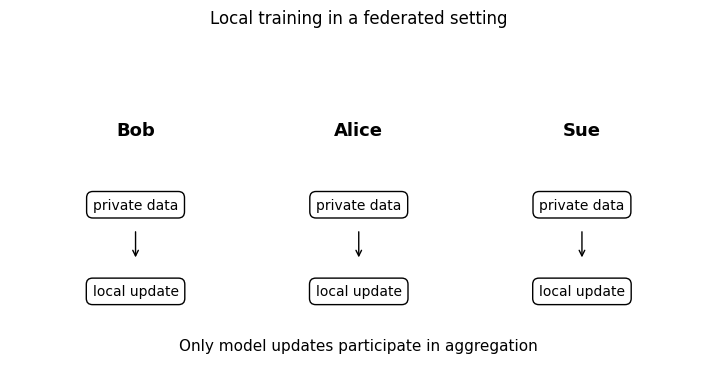

In [2]:
participants = ["Bob", "Alice", "Sue"]
data_location = ["local", "local", "local"]
model_update = ["local training", "local training", "local training"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axis("off")

for i, name in enumerate(participants):
    x = 0.18 + i * 0.32
    ax.text(x, 0.70, name, ha="center", fontsize=13, fontweight="bold")
    ax.text(x, 0.50, "private data", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.45", fill=False))
    ax.text(x, 0.25, "local update", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.45", fill=False))
    ax.annotate("", xy=(x,0.34), xytext=(x,0.43),
                arrowprops=dict(arrowstyle="->"))

ax.text(0.50, 0.08, "Only model updates participate in aggregation",
        ha="center", fontsize=11)
ax.set_title("Local training in a federated setting")
plt.show()

## Learning to Detect Spam

Buku menggunakan email classification sebagai contoh.

Dataset yang digunakan adalah **Enron email dataset**, dengan dua kelas:

- `spam`
- `ham`

Email diproses menjadi daftar index kata dan setiap email dibuat memiliki panjang **500 words** dengan trimming atau padding menggunakan `<unk>`.

In [3]:
# Small preprocessing demonstration.
example_email = ["my", "computer", "password", "is", "pizza"]
vocab = sorted(set(example_email + ["<unk>"]))
w2i = {w: i for i, w in enumerate(vocab)}

def to_indices(words, length=10):
    words = list(words[:length])
    words += ["<unk>"] * (length - len(words))
    return [w2i[w] for w in words]

encoded = to_indices(example_email)
print("Vocabulary:", vocab)
print("Encoded email:", encoded)
print("Length:", len(encoded))

Vocabulary: ['<unk>', 'computer', 'is', 'my', 'password', 'pizza']
Encoded email: [3, 1, 4, 2, 5, 0, 0, 0, 0, 0]
Length: 10


**Catatan:** demonstrasi di atas hanya menunjukkan mekanisme preprocessing. Source book menggunakan dataset `spam.txt` dan `ham.txt`, bukan contoh email pendek ini.

## Spam Model

Setelah preprocessing, book menggunakan model berbasis **Embedding** untuk mengubah word indices menjadi vector.

Struktur utamanya:

**word indices → Embedding → sum over words → sigmoid → spam probability**

Training menggunakan loss dan optimizer dari framework yang dibangun pada Chapter 13.

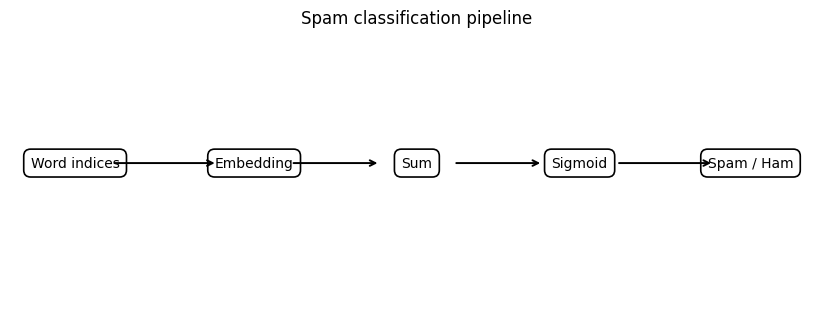

In [4]:
fig, ax = plt.subplots(figsize=(10.5, 3.8))
ax.axis("off")

steps = [
    ("Word indices", 0.08),
    ("Embedding", 0.30),
    ("Sum", 0.50),
    ("Sigmoid", 0.70),
    ("Spam / Ham", 0.91)
]

for label, x in steps:
    ax.text(x, 0.55, label, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.5", fill=False, linewidth=1.2))

for (_, x1), (_, x2) in zip(steps[:-1], steps[1:]):
    ax.annotate("", xy=(x2-0.045,0.55), xytext=(x1+0.045,0.55),
                arrowprops=dict(arrowstyle="->", linewidth=1.4))

ax.set_title("Spam classification pipeline")
plt.show()

## Source Result: Centralized Spam Classification

Setelah tiga training iterations, buku melaporkan test accuracy:

| Iteration | Test accuracy |
|---:|---:|
| 1 | 98.65% |
| 2 | 99.15% |
| 3 | 99.45% |

Dataset test pada contoh buku bersifat balanced.

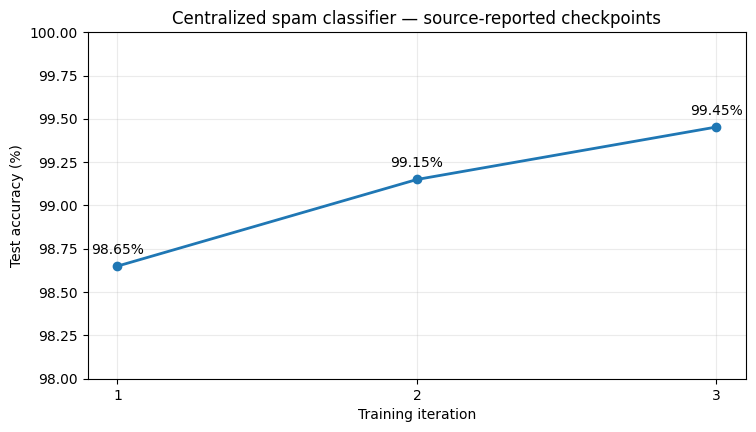

In [5]:
iterations = [1, 2, 3]
accuracy = [98.65, 99.15, 99.45286]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(iterations, accuracy, marker="o", linewidth=2)
ax.set_xticks(iterations)
ax.set_xlabel("Training iteration")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Centralized spam classifier — source-reported checkpoints")
ax.set_ylim(98, 100)
ax.grid(alpha=0.25)
for x, y in zip(iterations, accuracy):
    ax.annotate(f"{y:.2f}%", (x,y), xytext=(0,9),
                textcoords="offset points", ha="center")
plt.show()

## Let's Make It Federated

Dataset kemudian dibagi menjadi tiga local datasets:

- **Bob**
- **Alice**
- **Sue**

Setiap participant menerima copy model, melakukan local training, lalu model hasil training digabungkan dengan **averaging**.

Ini menunjukkan federated learning dalam bentuk sederhana yang digunakan buku.

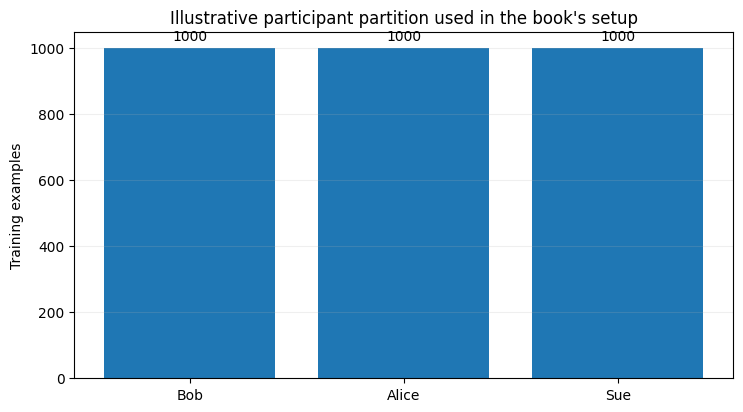

In [6]:
participants = ["Bob", "Alice", "Sue"]
dataset_sizes = [1000, 1000, 1000]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(participants, dataset_sizes)
ax.set_ylabel("Training examples")
ax.set_title("Illustrative participant partition used in the book's setup")
ax.grid(axis="y", alpha=0.2)
for bar, value in zip(bars, dataset_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, value + 25,
            str(value), ha="center")
plt.show()

Pada source, pembagian dibuat dengan pola:

`bob = (train_data[0:1000], train_target[0:1000])`

`alice = (train_data[1000:2000], train_target[1000:2000])`

`sue = (train_data[2000:], train_target[2000:])`

Kemudian model lokal di-average.

In [7]:
# Conceptual model averaging with three participant updates.
bob_update = np.array([0.20, -0.10, 0.40])
alice_update = np.array([0.10, 0.00, 0.20])
sue_update = np.array([0.30, -0.20, 0.10])

average_update = (bob_update + alice_update + sue_update) / 3

print("Bob update:", bob_update)
print("Alice update:", alice_update)
print("Sue update:", sue_update)
print("Average:", average_update)

Bob update: [ 0.2 -0.1  0.4]
Alice update: [0.1 0.  0.2]
Sue update: [ 0.3 -0.2  0.1]
Average: [ 0.2        -0.1         0.23333333]


**Catatan:** angka vector di atas adalah ilustrasi matematis untuk memperjelas averaging. Angka tersebut bukan output training source.

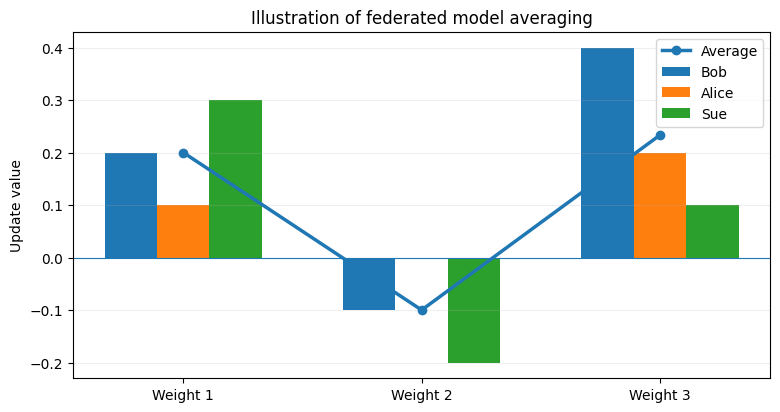

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(3)
width = 0.22

ax.bar(x - width, bob_update, width, label="Bob")
ax.bar(x, alice_update, width, label="Alice")
ax.bar(x + width, sue_update, width, label="Sue")
ax.plot(x, average_update, marker="o", linewidth=2.5,
        label="Average")

ax.axhline(0, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["Weight 1", "Weight 2", "Weight 3"])
ax.set_ylabel("Update value")
ax.set_title("Illustration of federated model averaging")
ax.legend()
ax.grid(axis="y", alpha=0.2)
plt.show()

## Source Result: Federated Training

Pada contoh source, federated model memperoleh sekitar **98.8% test accuracy** pada salah satu training round yang ditampilkan.

Hal pentingnya: performa model dapat tetap tinggi meskipun training dilakukan pada local datasets.

Namun, chapter kemudian menunjukkan bahwa **privacy belum otomatis terjamin hanya karena data mentah tidak dikirim**.

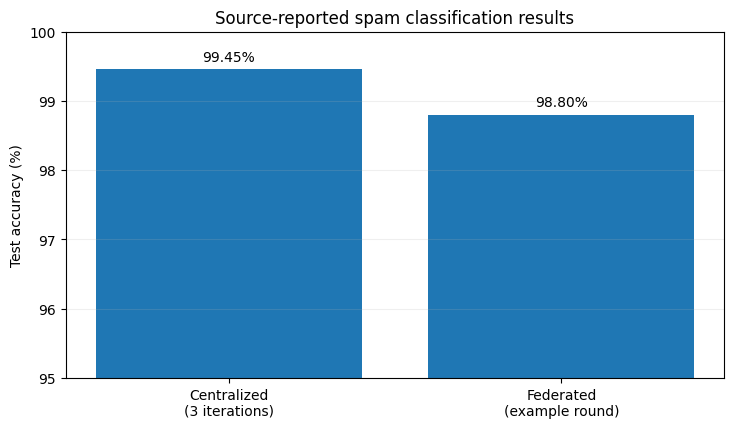

In [9]:
labels = ["Centralized\n(3 iterations)", "Federated\n(example round)"]
values = [99.45286, 98.8]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(labels, values)
ax.set_ylabel("Test accuracy (%)")
ax.set_ylim(95, 100)
ax.set_title("Source-reported spam classification results")
ax.grid(axis="y", alpha=0.2)
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.12,
            f"{value:.2f}%", ha="center")
plt.show()

## Hacking into Federated Learning

Masalah baru muncul ketika server melihat weight update dari participant.

Buku menggunakan toy example Bob dengan email:

`my computer password is pizza`

Bob melakukan satu local update. Dengan melihat weight mana yang berubah, seseorang dapat mengidentifikasi vocabulary yang berhubungan dengan email tersebut.

Jadi:

**Data tidak dikirim langsung ≠ informasi dari data pasti aman.**

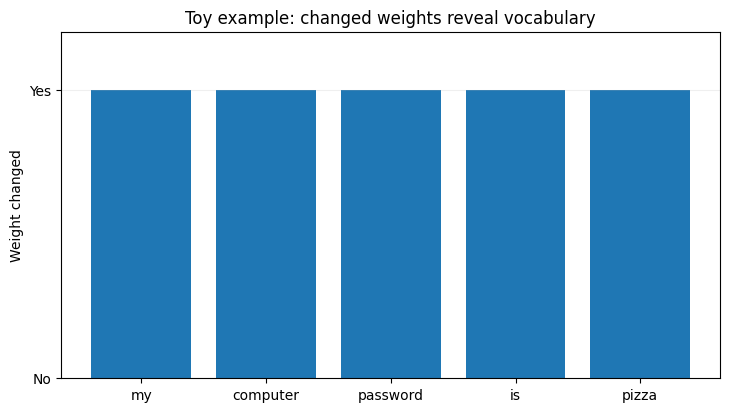

In [10]:
words = ["my", "computer", "password", "is", "pizza"]
changed = np.ones(len(words))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(words, changed)
ax.set_ylim(0, 1.2)
ax.set_ylabel("Weight changed")
ax.set_title("Toy example: changed weights reveal vocabulary")
ax.set_yticks([0, 1])
ax.set_yticklabels(["No", "Yes"])
ax.grid(axis="y", alpha=0.2)
plt.show()

Chart ini merepresentasikan contoh source secara konseptual: vocabulary yang associated dengan Bob's training example dapat diketahui dari weight changes. **Bukan hasil numerik model baru.**

## Secure Aggregation

Solusinya adalah tidak memperlihatkan update setiap participant secara individual.

Tujuannya:

**Bob update + Alice update + Sue update → aggregate update**

Server hanya membutuhkan hasil agregasi, bukan update individual.

Buku menghubungkan ide ini dengan **randomized response** dan **plausible deniability**: random noise dapat membuat suatu informasi sulit dikaitkan secara langsung dengan individu tertentu.

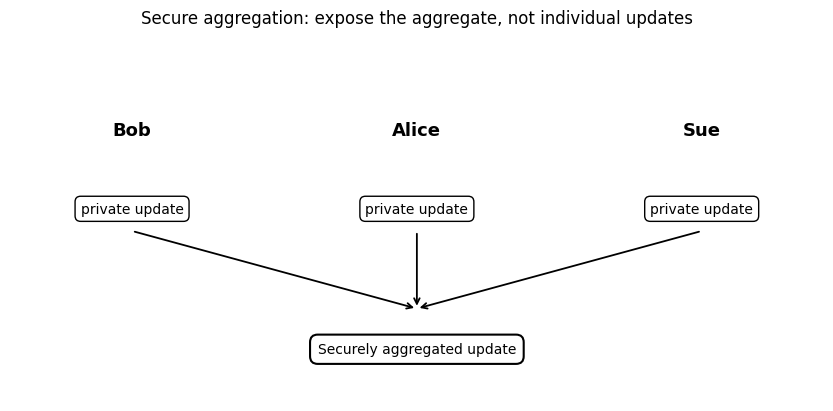

In [11]:
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.axis("off")

people = [("Bob",0.15),("Alice",0.50),("Sue",0.85)]
for name, x in people:
    ax.text(x, 0.72, name, ha="center", fontsize=13, fontweight="bold")
    ax.text(x, 0.52, "private update", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.4", fill=False))
    ax.annotate("", xy=(0.50,0.25), xytext=(x,0.46),
                arrowprops=dict(arrowstyle="->", linewidth=1.3))

ax.text(0.50, 0.14, "Securely aggregated update", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.55", fill=False, linewidth=1.5))
ax.set_title("Secure aggregation: expose the aggregate, not individual updates")
plt.show()

### Privacy via plausible deniability

Semakin banyak participant yang digabungkan sebelum hasil dilihat, semakin sulit menghubungkan aggregate dengan satu participant tertentu.

Buku menekankan bahwa menambahkan noise secara berlebihan dapat mengganggu training. Karena itu, secure aggregation digunakan untuk menggabungkan updates sebelum hasilnya terlihat.

## Homomorphic Encryption

**Homomorphic encryption** memungkinkan arithmetic dilakukan pada encrypted values tanpa mendekripsinya terlebih dahulu.

Dalam contoh chapter, fokusnya adalah **addition**.

Konsep:

`Encrypt(5) + Encrypt(3) → encrypted result → Decrypt → 8`

Dengan demikian, beberapa participant dapat menjumlahkan encrypted updates tanpa mengetahui isi update participant lainnya.

In [12]:
plaintext_a = 5
plaintext_b = 3

# Educational simulation of the arithmetic relationship.
# This is not an implementation of public-key cryptography.
encrypted_a = "Enc(5)"
encrypted_b = "Enc(3)"
encrypted_sum = "Enc(5 + 3)"
decrypted_sum = plaintext_a + plaintext_b

print("x =", encrypted_a)
print("y =", encrypted_b)
print("x + y =", encrypted_sum)
print("Decrypt(x + y) =", decrypted_sum)

x = Enc(5)
y = Enc(3)
x + y = Enc(5 + 3)
Decrypt(x + y) = 8


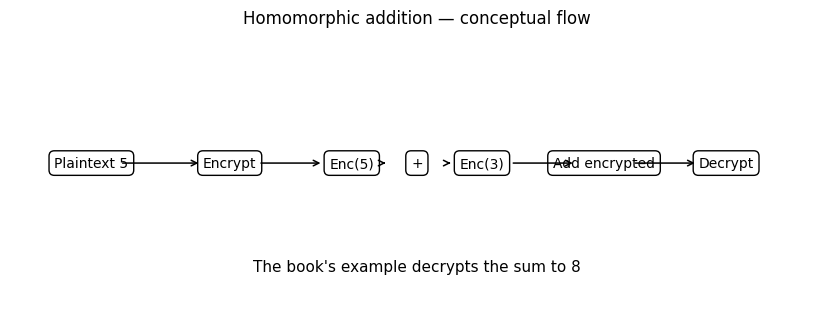

In [13]:
fig, ax = plt.subplots(figsize=(10.5, 3.8))
ax.axis("off")

steps = [
    ("Plaintext 5",0.10),
    ("Encrypt",0.27),
    ("Enc(5)",0.42),
    ("+",0.50),
    ("Enc(3)",0.58),
    ("Add encrypted",0.73),
    ("Decrypt",0.88)
]

for label, x in steps:
    ax.text(x, 0.55, label, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.38", fill=False))
for (_, x1), (_, x2) in zip(steps[:-1], steps[1:]):
    ax.annotate("", xy=(x2-0.035,0.55), xytext=(x1+0.035,0.55),
                arrowprops=dict(arrowstyle="->", linewidth=1.1))

ax.text(0.50, 0.18, "The book's example decrypts the sum to 8",
        ha="center", fontsize=11)
ax.set_title("Homomorphic addition — conceptual flow")
plt.show()

## Homomorphically Encrypted Federated Learning

Chapter kemudian menggabungkan dua ide:

1. Participant melakukan local training.
2. Model/update dienkripsi.
3. Participant mengirim encrypted update.
4. Encrypted updates dijumlahkan.
5. Hanya aggregate yang dikirim kembali.
6. Model owner melakukan decryption pada aggregate.

Dengan cara ini, participant tidak perlu membuka update individual mereka kepada pihak lain.

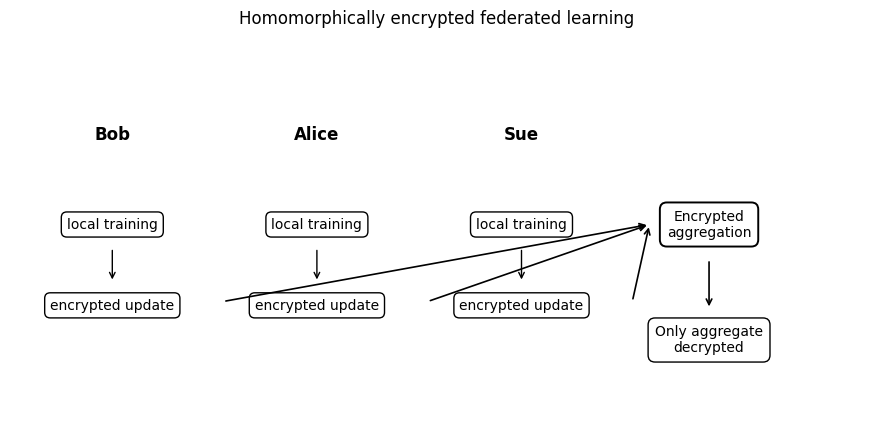

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis("off")

participants = [("Bob",0.12),("Alice",0.36),("Sue",0.60)]
for name, x in participants:
    ax.text(x, 0.72, name, ha="center", fontweight="bold", fontsize=12)
    ax.text(x, 0.50, "local training", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.4", fill=False))
    ax.text(x, 0.29, "encrypted update", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.4", fill=False))
    ax.annotate("", xy=(x,0.35), xytext=(x,0.44),
                arrowprops=dict(arrowstyle="->"))

ax.text(0.82, 0.50, "Encrypted\naggregation", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.5", fill=False, linewidth=1.4))
for x in [0.17,0.41,0.65]:
    ax.annotate("", xy=(0.75,0.50), xytext=(x+0.08,0.30),
                arrowprops=dict(arrowstyle="->", linewidth=1.2))

ax.text(0.82, 0.20, "Only aggregate\ndecrypted", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.5", fill=False))
ax.annotate("", xy=(0.82,0.28), xytext=(0.82,0.41),
            arrowprops=dict(arrowstyle="->", linewidth=1.2))

ax.set_title("Homomorphically encrypted federated learning")
plt.show()

## Source Code: Homomorphic Encryption Example

Source book menggunakan library `phe` dan Paillier cryptosystem untuk menunjukkan operasi sederhana:

```python
import phe

public_key, private_key = phe.generate_paillier_keypair(n_length=1024)

x = public_key.encrypt(5)
y = public_key.encrypt(3)
z = x + y

z_ = private_key.decrypt(z)
print("The Answer: " + str(z_))
```

Output yang dilaporkan:

`The Answer: 8`

Notebook ini tidak menjalankan library `phe` secara otomatis agar hasil notebook tidak bergantung pada package eksternal yang belum tentu tersedia.

In [15]:
# Reproduce the arithmetic result without requiring an external crypto package.
x = 5
y = 3
result = x + y
print("The Answer:", result)

The Answer: 8


## Homomorphically Encrypted Federated Learning — Source Setup

Source menggunakan:

- `Embedding(vocab_size=len(vocab), dim=1)`
- weight awal di-zero-kan
- Paillier public/private key
- `train_and_encrypt(...)`
- tiga participant: Bob, Alice, Sue
- encrypted models dijumlahkan
- aggregate didecrypt dan dibagi 3

Buku juga mencatat bahwa `n_length` untuk production seharusnya setidaknya **1024**, sedangkan contoh source menggunakan `128` pada bagian demonstrasi training.

In [16]:
config = {
    "embedding_dim": 1,
    "participants": 3,
    "production_key_length_note": 1024,
    "demonstration_key_length": 128,
}

for key, value in config.items():
    print(f"{key}: {value}")

embedding_dim: 1
participants: 3
production_key_length_note: 1024
demonstration_key_length: 128


## Source Result: Encrypted Federated Learning

Buku menampilkan contoh hasil training encrypted federated learning dengan test accuracy sekitar **99.15%** pada output yang ditampilkan.

Nilai ini adalah **source-reported result**.

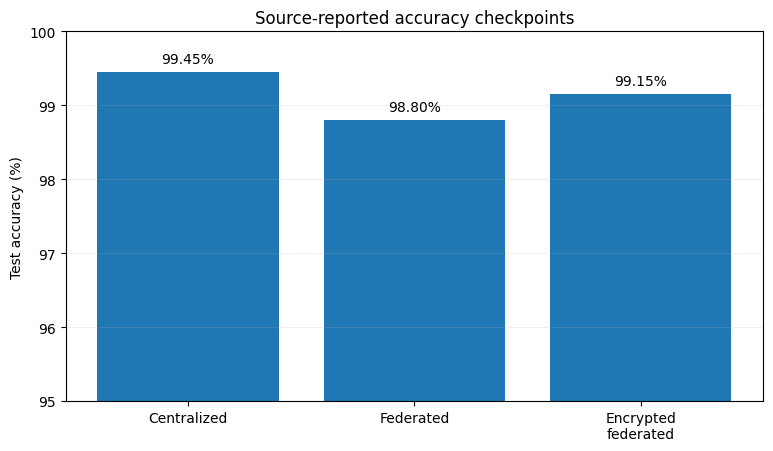

In [17]:
methods = ["Centralized", "Federated", "Encrypted\nfederated"]
results = [99.45286, 98.8, 99.15]

fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.bar(methods, results)
ax.set_ylabel("Test accuracy (%)")
ax.set_ylim(95, 100)
ax.set_title("Source-reported accuracy checkpoints")
ax.grid(axis="y", alpha=0.2)
for bar, value in zip(bars, results):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.12,
            f"{value:.2f}%", ha="center")
plt.show()

**Interpretasi penting:** ketiga angka berasal dari konteks training yang berbeda di dalam source dan bukan eksperimen perbandingan terkontrol dalam notebook ini. Chart hanya digunakan untuk membantu membaca reported checkpoints.

## Privacy Stack

Chapter 15 secara bertahap membangun beberapa lapisan perlindungan:

**Federated learning**  
→ data tetap berada di lokasi asal.

**Secure aggregation**  
→ individual model updates tidak dibuka secara langsung.

**Homomorphic encryption**  
→ operasi agregasi dapat dilakukan pada encrypted values.

Konsep-konsep tersebut saling melengkapi, bukan saling menggantikan.

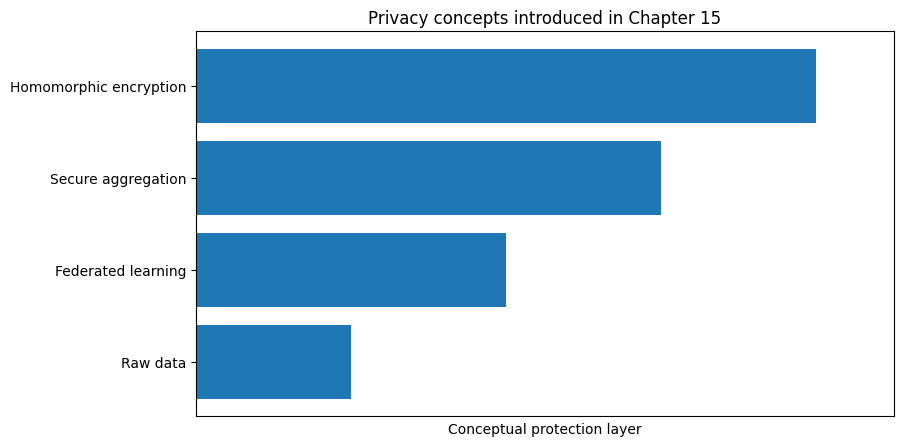

In [18]:
layers = ["Raw data", "Federated learning", "Secure aggregation",
          "Homomorphic encryption"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(layers, [1, 2, 3, 4])
ax.set_xlim(0, 4.5)
ax.set_xlabel("Conceptual protection layer")
ax.set_title("Privacy concepts introduced in Chapter 15")
ax.set_xticks([])
ax.grid(axis="x", alpha=0.15)
plt.show()

**Catatan:** angka 1–4 pada chart adalah urutan konsep, **bukan privacy score atau tingkat keamanan**.

## Concept Check

**1. Apa masalah utama centralized deep learning terhadap privacy?**  
Training membutuhkan akses terhadap data yang dapat bersifat personal atau sensitif.

**2. Apa ide utama federated learning?**  
Membawa model ke data, bukan mengumpulkan seluruh data ke satu tempat.

**3. Mengapa federated learning saja belum cukup?**  
Karena weight update dapat membawa informasi yang memungkinkan seseorang menginfer data lokal.

**4. Apa tujuan secure aggregation?**  
Menggabungkan updates sehingga individual update tidak perlu terlihat secara langsung.

**5. Apa yang membuat homomorphic encryption menarik?**  
Arithmetic dapat dilakukan pada encrypted values tanpa harus mendekripsinya terlebih dahulu.

**6. Apa hubungan secure aggregation dan homomorphic encryption?**  
Homomorphic encryption dapat digunakan untuk memungkinkan aggregation terhadap encrypted updates.

## Key Takeaways

- Training data dapat mengandung informasi yang sangat sensitif.
- **Federated learning** memungkinkan model belajar tanpa memusatkan raw data.
- Weight updates tetap dapat menjadi sumber information leakage.
- **Secure aggregation** menyembunyikan individual updates melalui aggregation.
- **Homomorphic encryption** memungkinkan operasi tertentu pada encrypted values.
- Chapter ini menggabungkan federated learning dengan encryption untuk meningkatkan privacy.
- Privacy bukan hanya masalah memindahkan atau tidak memindahkan raw data; **model updates juga perlu diperhatikan**.

## Chapter Summary

Chapter 15 membahas privacy sebagai tantangan penting dalam deep learning. Federated learning menawarkan pendekatan dengan membawa model ke lokasi data sehingga raw data tidak perlu dipusatkan. Contoh spam classification menunjukkan bahwa pendekatan ini tetap dapat menghasilkan performa tinggi.

Namun, model update dapat membocorkan informasi tentang training data. Karena itu, chapter memperkenalkan secure aggregation dan homomorphic encryption. Secure aggregation berfokus pada agregasi tanpa membuka individual updates, sedangkan homomorphic encryption memungkinkan arithmetic pada encrypted values. Kombinasi konsep tersebut menjadi dasar pendekatan privacy-preserving federated learning yang dibahas pada bagian akhir chapter.

## Reference

Trask, A. W. (2019). *Grokking Deep Learning*. Manning Publications.

Chapter 15: *Deep learning on unseen data: introducing federated learning*.